In [1]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
DATASET_PATH = r"D:/Akademik/SEMESTER 3/Pengolahan Sinyal Digital Sem 3/Proyek_PSD/for-2seconds"

TRAIN_PATH = os.path.join(DATASET_PATH, "Training")
VAL_PATH   = os.path.join(DATASET_PATH, "Validation")
TEST_PATH  = os.path.join(DATASET_PATH, "Testing")


In [ ]:
def preprocess_audio(audio, sr, duration=2.0):
    target_length = int(sr * duration)

    if len(audio) > target_length:
        audio = audio[:target_length]

    else:
        padding = target_length - len(audio)
        audio = np.pad(audio, (0, padding), mode='constant')

    audio = audio / np.max(np.abs(audio) + 1e-9)

    return audio


In [ ]:
def load_audio_files(folder_path, sample_rate=16000):
    X = []
    y = []

    for label, class_name in enumerate(["Real", "Fake"]):
        class_folder = os.path.join(folder_path, class_name)

        for file_name in os.listdir(class_folder):
            if file_name.endswith(".wav"):
                file_path = os.path.join(class_folder, file_name)

                audio, sr = librosa.load(
                    file_path,
                    sr=sample_rate,
                    mono=True
                )

                X.append(audio)
                y.append(label)

    return X, np.array(y)


In [5]:
X_train, y_train = load_audio_files(TRAIN_PATH)
X_val, y_val     = load_audio_files(VAL_PATH)
X_test, y_test   = load_audio_files(TEST_PATH)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

Training samples: 13956
Validation samples: 2826
Testing samples: 1088


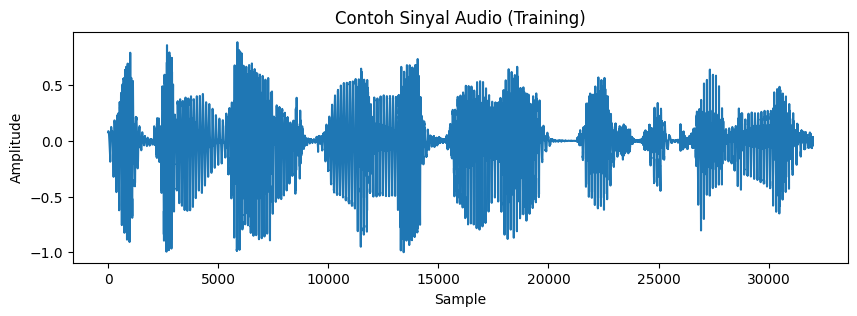

Label: Real


In [6]:
plt.figure(figsize=(10, 3))
plt.plot(X_train[1])
plt.title("Contoh Sinyal Audio (Training)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

print("Label:", "Real" if y_train[0] == 0 else "Fake")

In [ ]:
def extract_logmel_spectrogram(
    audio,
    sr=16000,
    n_fft=1024,
    hop_length=256,
    n_mels=64
):

    mel_spec = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )


    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

    return log_mel_spec


In [8]:
def process_dataset(X, sr=16000):
    features = []

    for audio in X:
        audio = preprocess_audio(audio, sr)
        logmel = extract_logmel_spectrogram(audio, sr)
        features.append(logmel)

    return np.array(features)


In [9]:
X_train_spec = process_dataset(X_train)
X_val_spec   = process_dataset(X_val)
X_test_spec  = process_dataset(X_test)

print("Train spectrogram shape:", X_train_spec.shape)
print("Validation spectrogram shape:", X_val_spec.shape)
print("Test spectrogram shape:", X_test_spec.shape)

Train spectrogram shape: (13956, 64, 126)
Validation spectrogram shape: (2826, 64, 126)
Test spectrogram shape: (1088, 64, 126)


In [ ]:
def prepare_for_cnn(X):
    X = (X - np.min(X)) / (np.max(X) - np.min(X) + 1e-9)
    X = X[..., np.newaxis]
    
    return X


In [11]:
X_train_cnn = prepare_for_cnn(X_train_spec)
X_val_cnn   = prepare_for_cnn(X_val_spec)
X_test_cnn  = prepare_for_cnn(X_test_spec)

print("CNN input shape:", X_train_cnn.shape)

CNN input shape: (13956, 64, 126, 1)


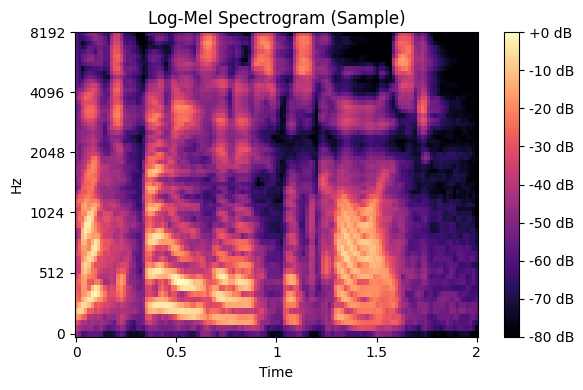

Label: Real


In [12]:
plt.figure(figsize=(6, 4))
librosa.display.specshow(
    X_train_spec[0],
    sr=16000,
    hop_length=256,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar(format='%+2.0f dB')
plt.title("Log-Mel Spectrogram (Sample)")
plt.tight_layout()
plt.show()

print("Label:", "Real" if y_train[0] == 0 else "Fake")

In [13]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout
)
from tensorflow.keras.optimizers import Adam

In [15]:
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(64, 126, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])


c:\Users\MyBook Hype AMD\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 124, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 62, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 60, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,376,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,399,681 (5.34 MB)

 Trainable params: 1,399,681 (5.34 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=20,
    batch_size=32,
    shuffle=True
)

Epoch 1/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 91s 187ms/step - accuracy: 0.7274 - loss: 0.5285 - val_accuracy: 0.8369 - val_loss: 0.3671
Epoch 2/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 53s 121ms/step - accuracy: 0.8248 - loss: 0.3554 - val_accuracy: 0.9172 - val_loss: 0.2033
Epoch 3/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 41s 94ms/step - accuracy: 0.8973 - loss: 0.2169 - val_accuracy: 0.9437 - val_loss: 0.1293
Epoch 4/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 50s 114ms/step - accuracy: 0.9332 - loss: 0.1403 - val_accuracy: 0.9600 - val_loss: 0.0866
Epoch 5/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 47s 107ms/step - accuracy: 0.9453 - loss: 0.1131 - val_accuracy: 0.9756 - val_loss: 0.0642
Epoch 6/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 47s 107ms/step - accuracy: 0.9651 - loss: 0.0770 - val_accuracy: 0.9823 - val_loss: 0.0506
Epoch 7/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 40s 91ms/step - accuracy: 0.9741 - loss: 0.0698 - val_accuracy: 0.9671 - val_loss: 0.0950
Epoch 8/20
437/437 ━━━━━━━━━━━━━━━━━━━━ 47s 108ms/step - accuracy: 0.9814 - loss: 0.0

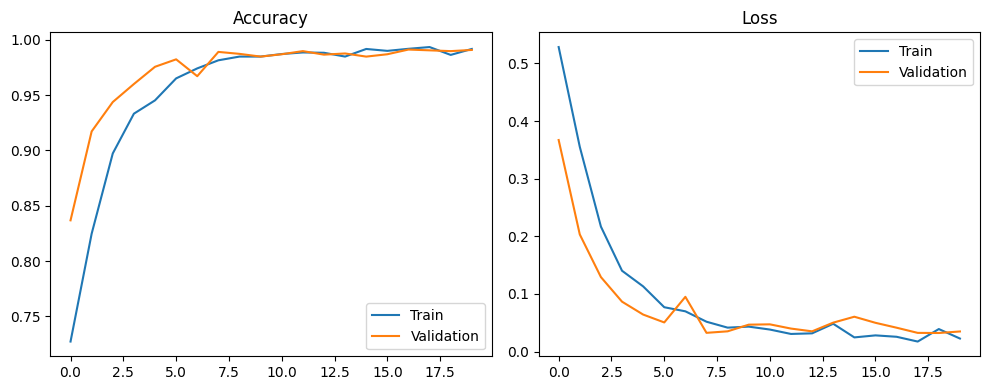

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
test_loss, test_acc = model.evaluate(X_test_cnn, y_test, verbose=0)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

Test Accuracy : 0.8373
Test Loss     : 0.6003


In [21]:
y_pred_prob = model.predict(X_test_cnn)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step


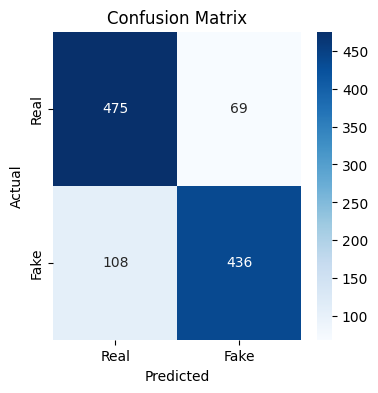

In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [23]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Real", "Fake"]
))

              precision    recall  f1-score   support

        Real       0.81      0.87      0.84       544
        Fake       0.86      0.80      0.83       544

    accuracy                           0.84      1088
   macro avg       0.84      0.84      0.84      1088
weighted avg       0.84      0.84      0.84      1088



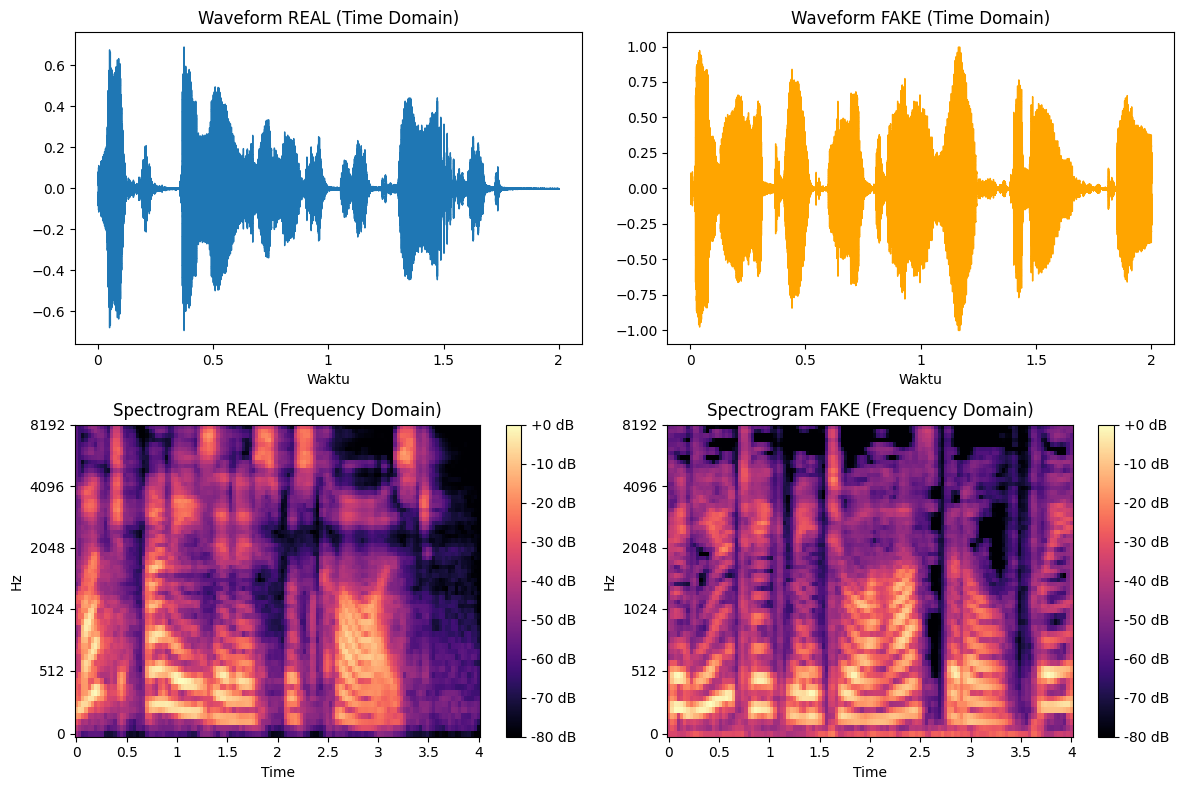

In [ ]:
import librosa.display

idx_real = np.where(y_train == 0)[0][0]
idx_fake = np.where(y_train == 1)[0][0]

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
librosa.display.waveshow(X_train[idx_real], sr=16000)
plt.title("Waveform REAL (Time Domain)")
plt.xlabel("Waktu")

plt.subplot(2, 2, 2)
librosa.display.waveshow(X_train[idx_fake], sr=16000, color='orange')
plt.title("Waveform FAKE (Time Domain)")
plt.xlabel("Waktu")

plt.subplot(2, 2, 3)
librosa.display.specshow(X_train_spec[idx_real], sr=16000, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram REAL (Frequency Domain)")

plt.subplot(2, 2, 4)
librosa.display.specshow(X_train_spec[idx_fake], sr=16000, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram FAKE (Frequency Domain)")

plt.tight_layout()
plt.show()

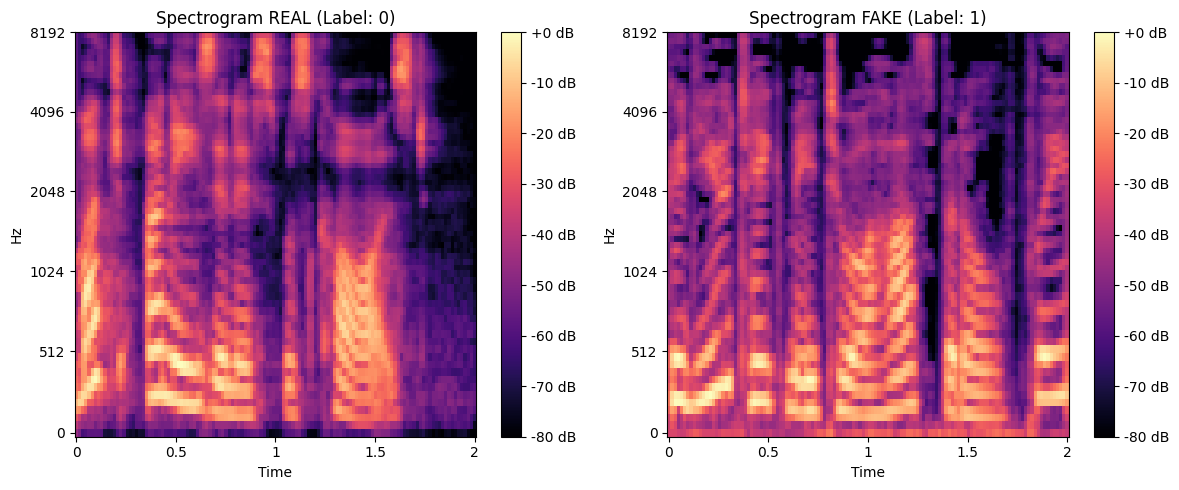

In [26]:
idx_real = np.where(y_train == 0)[0][0]
idx_fake = np.where(y_train == 1)[0][0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
librosa.display.specshow(X_train_spec[idx_real], sr=16000, hop_length=256, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Spectrogram REAL (Label: 0)")

plt.subplot(1, 2, 2)
librosa.display.specshow(X_train_spec[idx_fake], sr=16000, hop_length=256, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Spectrogram FAKE (Label: 1)")

plt.tight_layout()
plt.show()

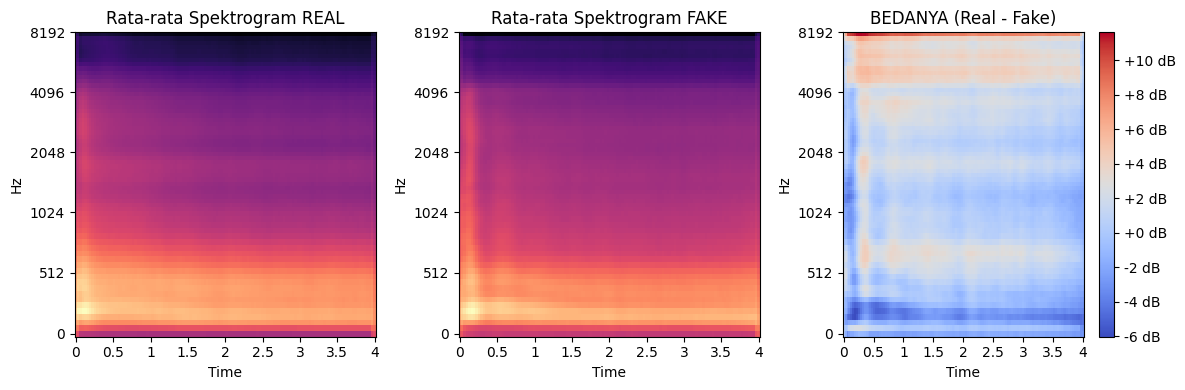

In [27]:
mean_real = np.mean(X_train_spec[y_train == 0], axis=0)
mean_fake = np.mean(X_train_spec[y_train == 1], axis=0)
diff_spec = mean_real - mean_fake

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
librosa.display.specshow(mean_real, sr=16000, x_axis='time', y_axis='mel')
plt.title("Rata-rata Spektrogram REAL")

plt.subplot(1, 3, 2)
librosa.display.specshow(mean_fake, sr=16000, x_axis='time', y_axis='mel')
plt.title("Rata-rata Spektrogram FAKE")

plt.subplot(1, 3, 3)
librosa.display.specshow(diff_spec, sr=16000, x_axis='time', y_axis='mel', cmap='coolwarm')
plt.colorbar(format='%+2.0f dB')
plt.title("BEDANYA (Real - Fake)")

plt.tight_layout()
plt.show()

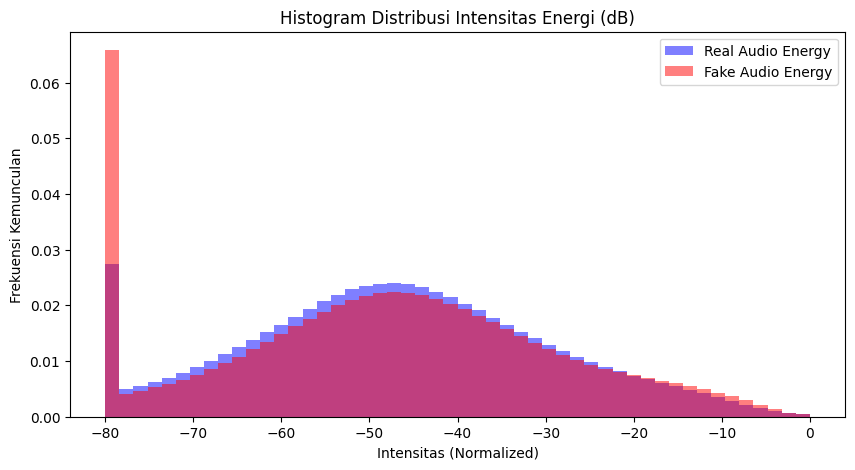

In [ ]:
real_values = X_train_spec[y_train == 0].flatten()
fake_values = X_train_spec[y_train == 1].flatten()

plt.figure(figsize=(10, 5))
plt.hist(real_values, bins=50, alpha=0.5, color='blue', label='Real Audio Energy', density=True)
plt.hist(fake_values, bins=50, alpha=0.5, color='red', label='Fake Audio Energy', density=True)
plt.legend()
plt.title("Histogram Distribusi Intensitas Energi (dB)")
plt.xlabel("Intensitas (Normalized)")
plt.ylabel("Frekuensi Kemunculan")
plt.show()